### Análisis de Datos

In [894]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [895]:
casas_dev = pd.read_csv("casas_dev.csv")
casas_test = pd.read_csv("casas_test.csv")

casas_dev_df = casas_dev.copy()
casas_test_df = casas_test.copy()

In [896]:
print('shape = ', casas_dev_df.shape)
casas_dev_df.sample(7)

shape =  (900, 9)


,area,area_units,is_house,has_pool,age,price,lat,lon,rooms
595,96.0,m2,1,0,11.0,187.0,-34.639193,-58.392013,3.0
518,1442.0,sqft,0,0,15.0,967.0,40.689484,-74.002924,4.0
730,915.0,sqft,0,0,4.0,639.0,40.739866,-74.038101,2.0
183,1485.0,sqft,0,0,14.0,989.0,40.682601,-73.972086,4.0
139,1130.0,sqft,0,1,5.0,903.0,40.690536,-74.013991,3.0
117,506.0,sqft,0,0,13.0,341.0,40.712694,-73.959447,NaN
679,65.0,m2,1,0,11.0,119.0,-34.630404,-58.319213,2.0


In [897]:
print('shape = ', casas_test_df.shape)
casas_test_df.sample(7)

shape =  (100, 9)


,area,area_units,is_house,has_pool,age,price,lat,lon,rooms
7,60.0,m2,1,0,17.0,106.0,-34.668051,-58.431041,2.0
0,65.0,m2,0,1,8.0,120.0,-34.605351,-58.406746,2.0
38,990.0,sqft,0,0,14.0,1111.0,40.713660,-74.005728,3.0
80,1259.0,sqft,1,0,9.0,1094.0,40.722695,-74.045105,4.0
17,134.0,m2,0,1,5.0,488.0,-34.604883,-58.379281,4.0
32,678.0,sqft,0,0,NaN,470.0,40.739068,-73.982893,NaN
63,79.0,m2,0,0,NaN,124.0,-34.632125,-58.444064,2.0


In [898]:
def valores_faltantes(df):
    print("\nValores faltantes por columna:")
    print(df.isna().sum())

def porcentajes_faltantes(df):
    total_filas = len(df)
    
    n_nan_age = df["age"].isna().sum()
    porcentaje_nan_age = (n_nan_age / total_filas) * 100
    
    n_nan_rooms = df["rooms"].isna().sum()
    porcentaje_nan_rooms = (n_nan_rooms / total_filas) * 100

    print(f"Valores NaN en 'age': {n_nan_age} sobre un total de {total_filas} filas ({porcentaje_nan_age:.2f}%)")
    print(f"Valores NaN en 'rooms': {n_nan_rooms} sobre un total de {total_filas} filas ({porcentaje_nan_rooms:.2f}%)")

valores_faltantes(casas_dev_df)
porcentajes_faltantes(casas_dev_df)



Valores faltantes por columna:
area            0
area_units      0
is_house        0
has_pool        0
age           130
price           0
lat             0
lon             0
rooms          72
dtype: int64
Valores NaN en 'age': 130 sobre un total de 900 filas (14.44%)
Valores NaN en 'rooms': 72 sobre un total de 900 filas (8.00%)


Dropear 14.44% y/o 8% de los datos por una feature faltante sería desperdiciar mucha información por lo que intentaremos estimar estos valores faltantes. Para eso, anaelicemos el resto de las features y sus correlaciones.

In [899]:
valores_faltantes(casas_test_df)
porcentajes_faltantes(casas_test_df)


Valores faltantes por columna:
area           0
area_units     0
is_house       0
has_pool       0
age           16
price          0
lat            0
lon            0
rooms          4
dtype: int64
Valores NaN en 'age': 16 sobre un total de 100 filas (16.00%)
Valores NaN en 'rooms': 4 sobre un total de 100 filas (4.00%)


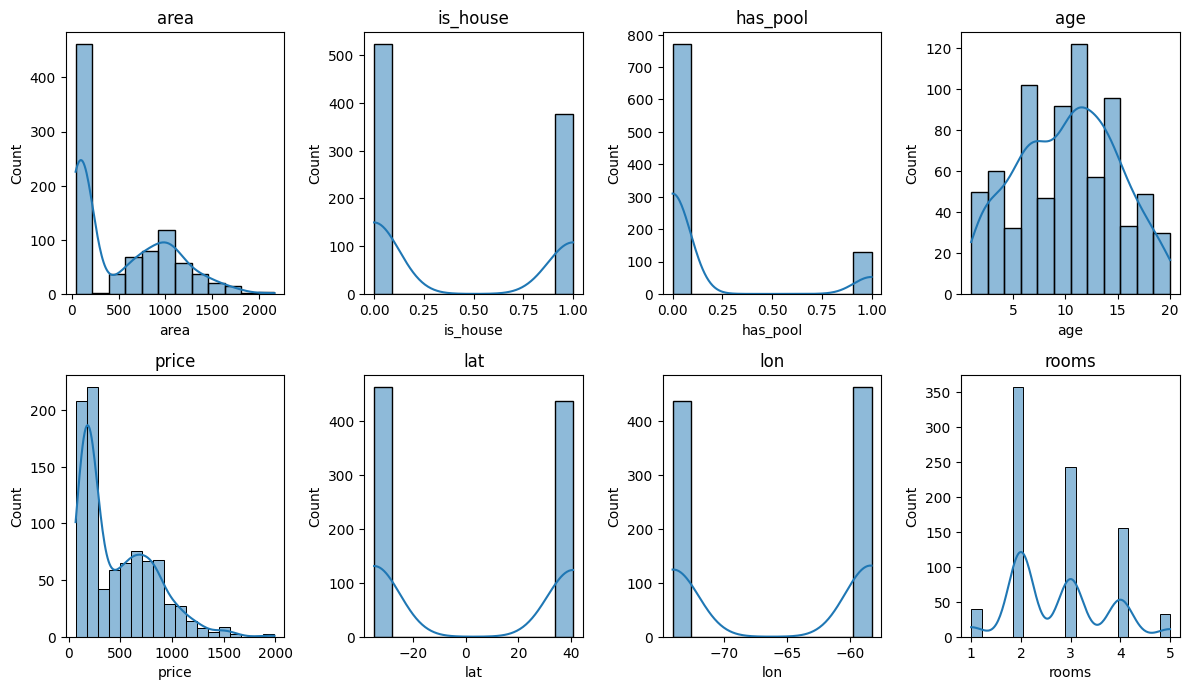

In [900]:
def plot_distributions(df):
    to_plot = df.select_dtypes(include='number') # .columns.drop(['is_house', 'has_pool'])

    plt.figure(figsize=(12, 10))
    for i, col in enumerate(to_plot, 1):
        plt.subplot(3, 4, i)
        sns.histplot(df[col], kde=True)
        plt.title(col)
    plt.tight_layout()
    plt.show()
    
plot_distributions(casas_dev_df)

##### Revisión de unidades

In [901]:
print(casas_dev_df['area_units'].value_counts())

area_units
m2      463
sqft    437
Name: count, dtype: int64


In [902]:
def area_units_conversion(df):
    sqft_to_m2 = 1 / 10.76389999 # factor de conversión de sqft a m2

    df.loc[df['area_units'] == 'sqft', 'area'] *= sqft_to_m2

    df.drop('area_units', axis=1, inplace=True)
    
area_units_conversion(casas_dev_df)

In [903]:
print(casas_test_df['area_units'].value_counts())

area_units
m2      53
sqft    47
Name: count, dtype: int64


In [904]:
area_units_conversion(casas_test_df)

Ahora sí podemos visualizar las distribuciones

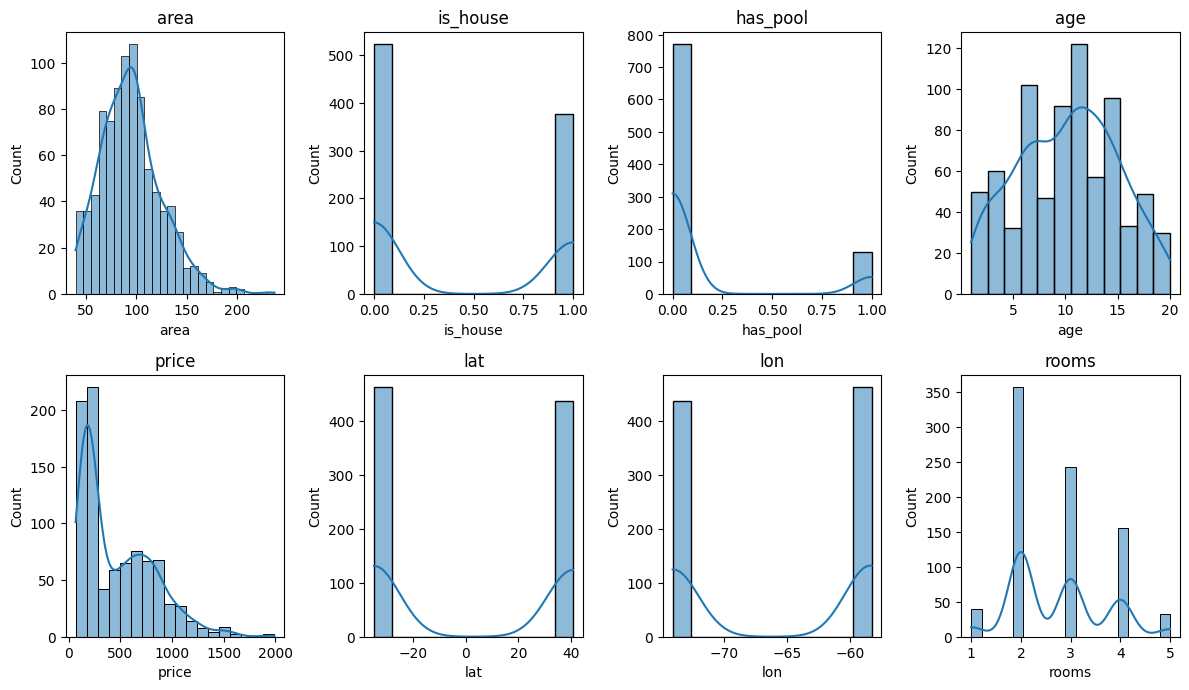

In [905]:
plot_distributions(casas_dev_df)

ahora se puede visualizar mejor la distribución de área, que parece estar levemente sesgada a derecha si asumimos que los datos vienen de una distribución normal, o incluso parece una chi-cuadrado.

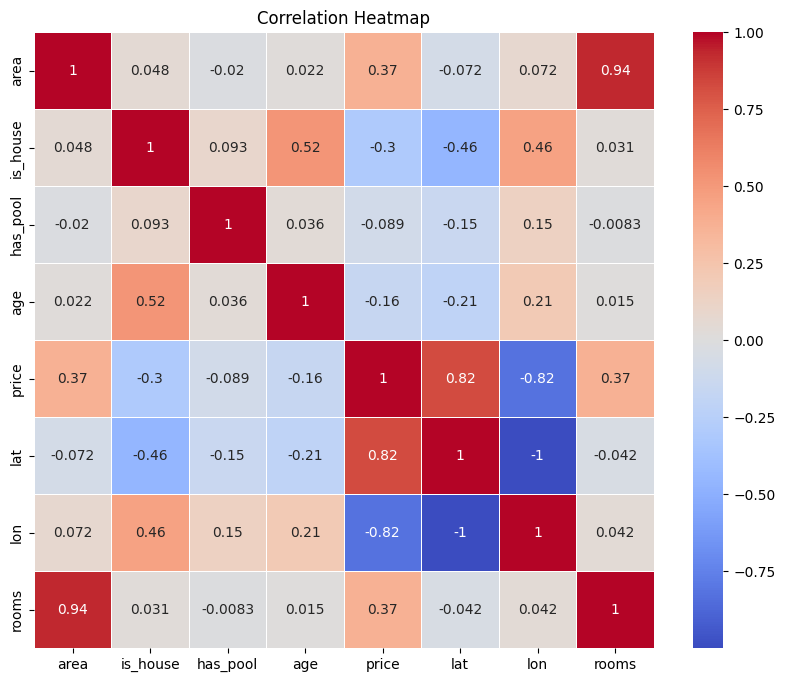

In [906]:
def plot_correlation(df):
    df_numeric = df.select_dtypes(include=['number'])
    correlation_matrix = df_numeric.corr()

    plt.figure(figsize=(10, 8)) 
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
    plt.title("Correlation Heatmap")
    plt.show()
    
plot_correlation(casas_dev_df)

##### estandarizamos o escalamos los datos según corresponde

hacemos estandarización (Z-score normalization) cuando la variable sigue una distribución aproximadamente normal
$$x' = \frac{x - \mu}{\sigma}$$

Y hacemos reescalado cuando cuando los datos no son normales
Una opción común es Min-Max Scaling:
$$x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

Estandarizo:  
age (aproximadamente normal), rooms (discreta pero la estandarización ayuda)

Reescalo:   
lat y lon (son cíclicas y no son normales, tienen concentraciones en los extremos)  
lat_sin=sin(lat)  
lat_cos=cos(lat)  
lon_sin=sin(lon)  
lon_cos=cos(lon)  
donde sus valores están en [−1,1] de forma natural  
pero las variables van a estar muy correlacionadas por lo que después de esto hay que hacer PCA sobre estas

area y price están sesgadas a la derecha (colas largas)  
price = log(price + 1) (y hago un ajuste inverso después de la predicción)  
area = log(area + 1) y después estandarizar  
El log hace que los valores grandes no dominen el modelo y mejora la linealidad

No hago nada con las binarias: has_pool, is_house


In [907]:
from funciones_auxiliares import normalize_var

In [908]:
def scale_df(df):
    df['age'] = normalize_var(df['age'])
    df['rooms'] = normalize_var(df['rooms'])

    df['lat_sin'] = np.sin(df['lat'])
    df['lat_cos'] = np.cos(df['lat'])
    df['lon_sin'] = np.sin(df['lon'])
    df['lon_cos'] = np.cos(df['lon'])

    df['area'] = np.log(df['area'] + 1)
    df['price'] = np.log(df['price'] + 1)

    df['area'] = normalize_var(df['area'])

    # Las columnas binarias se mantienen igual -> is_house y has_pool no se transforman

    # Eliminamos lat y lon originales porque ya transformamos
    df = df.drop(columns=['lat', 'lon'])
    
    return df

casas_transformed = scale_df(casas_dev_df)

casas_transformed.head()

,area,is_house,has_pool,age,price,rooms,lat_sin,lat_cos,lon_sin,lon_cos
0,-1.306361,1,0,1.632528,6.304449,-0.778398,0.160938,-0.986965,0.983769,0.179439
1,0.382622,0,0,-0.254300,6.633318,0.276452,0.127517,-0.991836,0.990171,0.139863
2,-1.155246,0,0,-0.673595,6.142037,-0.778398,0.170012,-0.985442,0.979670,0.200616
3,1.061340,1,1,1.213233,5.529429,1.331303,0.042905,-0.999079,-0.956569,-0.291507
4,1.086152,0,0,-0.463947,6.871091,1.331303,0.118106,-0.993001,0.987887,0.155172


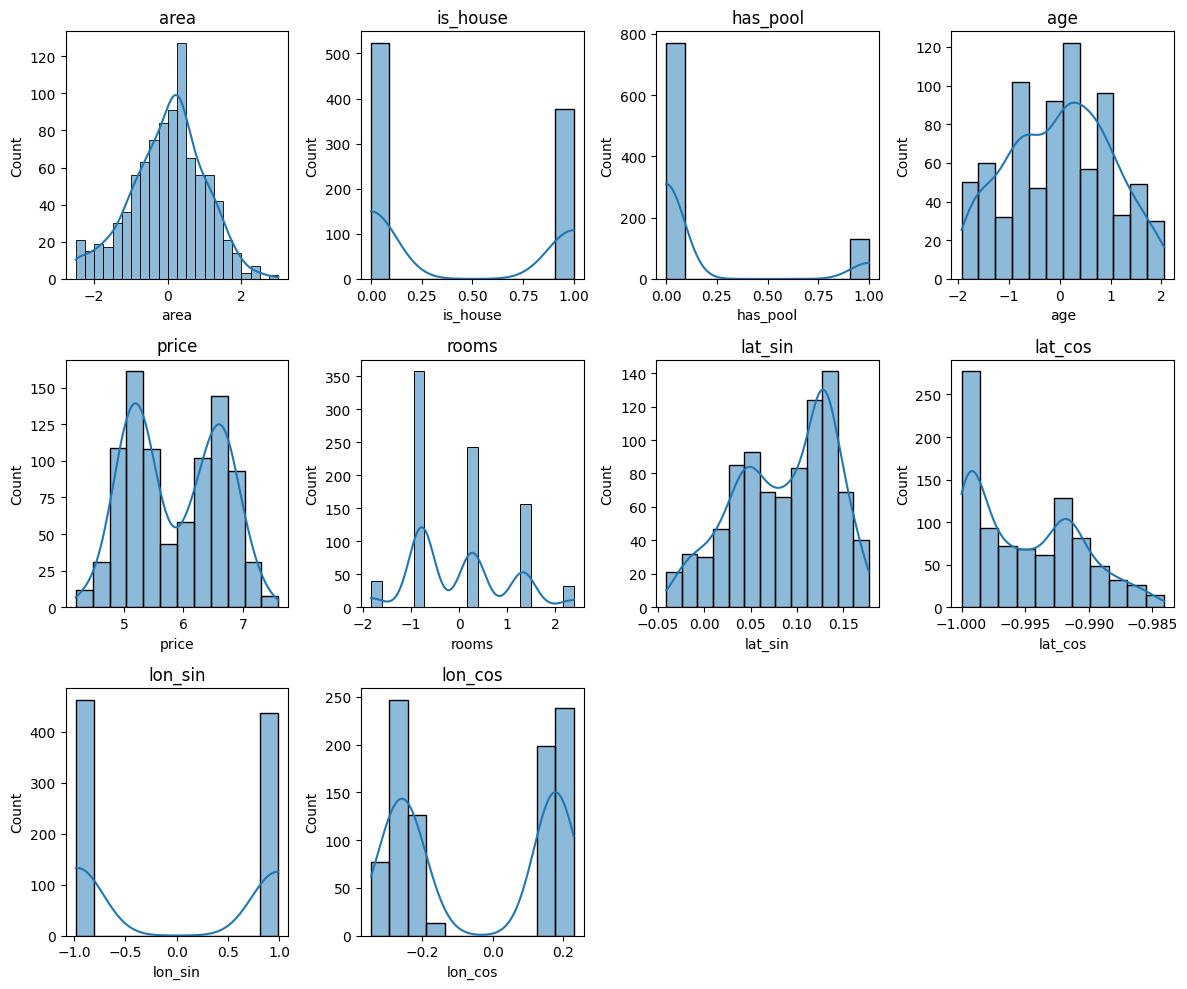

In [909]:
plot_distributions(casas_transformed)

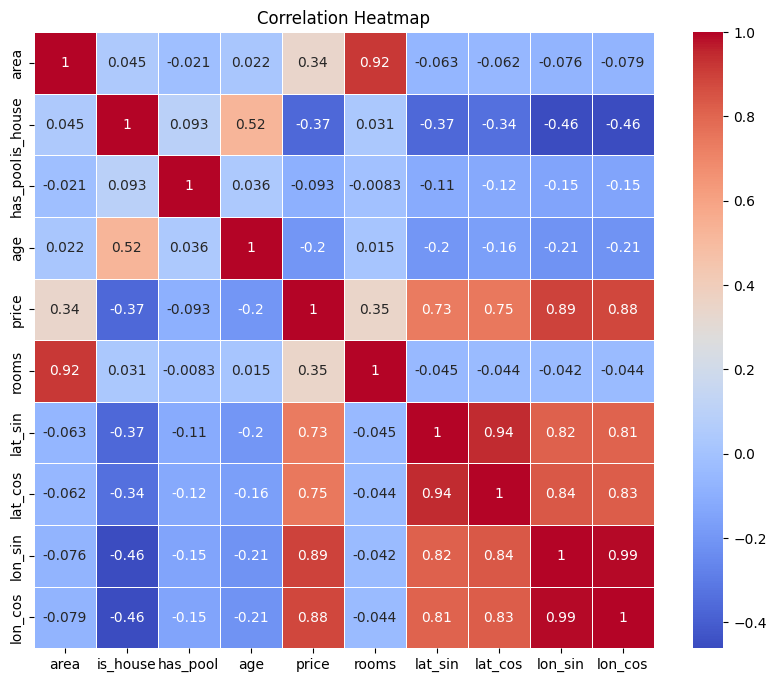

In [910]:
plot_correlation(casas_transformed)

In [911]:
from funciones_auxiliares import pca_with_svd

In [912]:
def pca_latlon(df):
    X_pca = df[['lat_sin', 'lat_cos', 'lon_sin', 'lon_cos']].values
    Z, U_d, S_d, VT_d = pca_with_svd(X_pca, d=2)

    df['pca_latlon_1'] = Z[:, 0]
    df['pca_latlon_2'] = Z[:, 1]
    df = df.drop(columns=['lat_sin', 'lat_cos', 'lon_sin', 'lon_cos'])
    
    explained_variance = (S_d ** 2) / np.sum(S_d ** 2)
    print(f"Varianza explicada por cada componente: {explained_variance}")
    
    # la segunda componente no explica casi varianza, por lo que nos vamos a quedar con la primera
    df = df.drop(columns=['pca_latlon_2'])
    
    return df

casas_transformed = pca_latlon(casas_transformed)


Varianza explicada por cada componente: [[0.89163839 0.        ]
 [0.         0.10836161]]


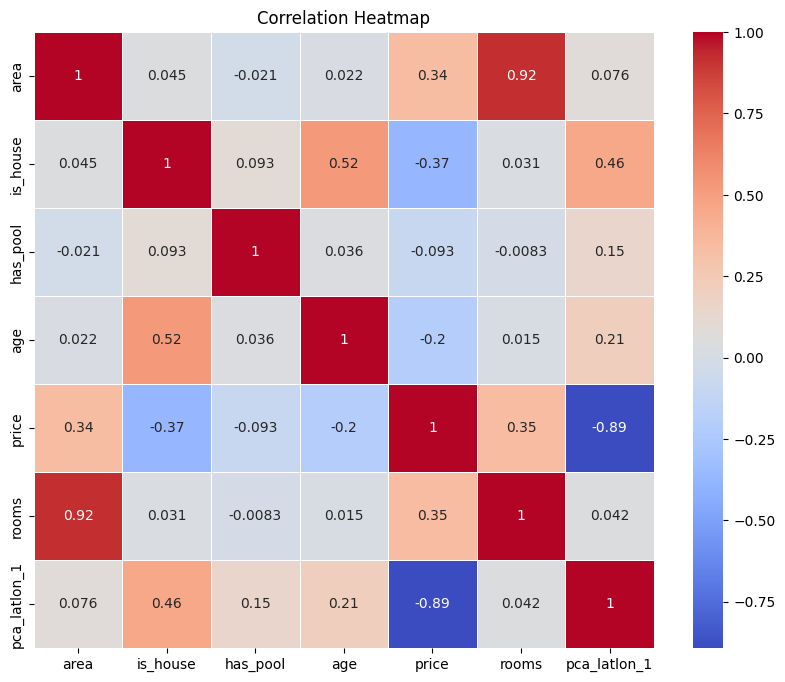

In [913]:
plot_correlation(casas_transformed)

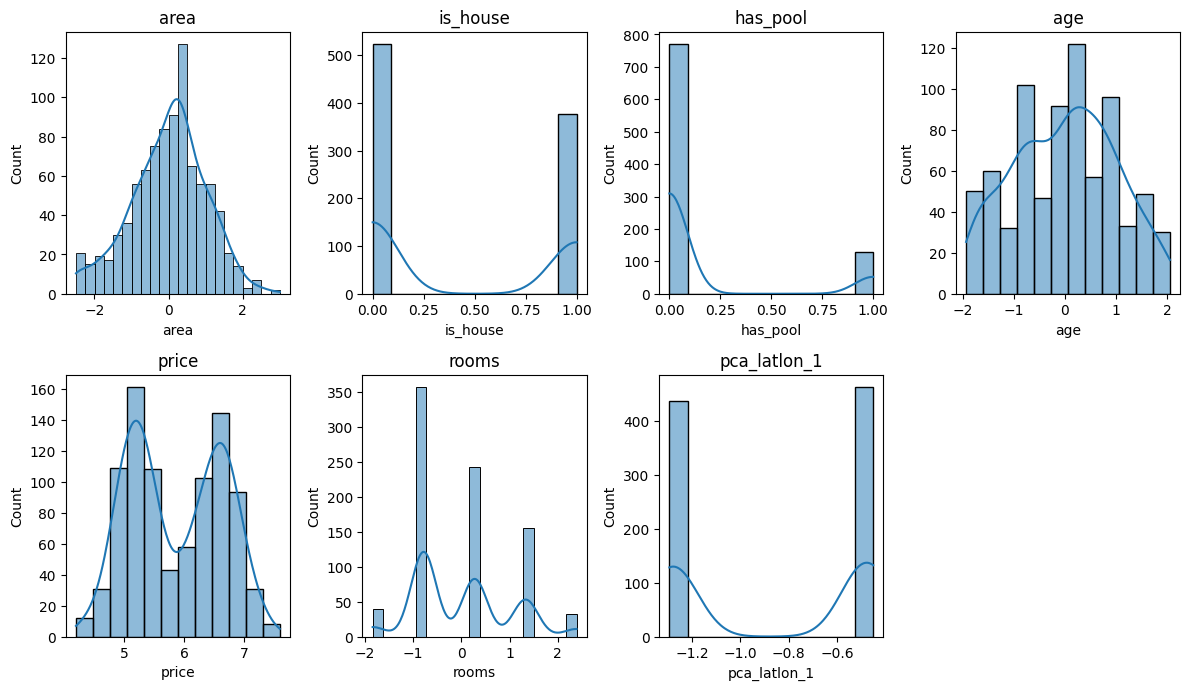

In [914]:
plot_distributions(casas_transformed)



#### Solucionamos ahora los problemas de nulls

estimo las ages que faltan, con aprendizaje supervisado utilizando las features que más correlacion en módulo tienen con age $\rightarrow$ is_house, price, pca_latlon_1

In [ ]:

def estimate_null_ages(df):
    features = ['is_house', 'pca_latlon_1', 'price', 'area']

    train = df.dropna(subset=['age']).copy()

    # Separar datos donde 'age' es nulo (para predecir luego)
    test = df[df['age'].isna()].copy()

    n = len(train)
    n_train = int(n * 0.8)  # 80% de los datos para entrenar

    # Mezclar los datos aleatoriamente
    train = train.sample(frac=1, random_state=42).reset_index(drop=True)

    # Separar en conjunto de entrenamiento y validación
    train_data = train.iloc[:n_train]
    valid_data = train.iloc[n_train:]

    # Extraer X e y
    X_train = train_data[features].values
    y_train = train_data['age'].values

    X_valid = valid_data[features].values
    y_valid = valid_data['age'].values

    # Agregar columna de unos para el término independiente (bias)
    X_train = np.hstack([np.ones((X_train.shape[0], 1)), X_train])
    X_valid = np.hstack([np.ones((X_valid.shape[0], 1)), X_valid])

    # ===============================
    # 4️⃣ Ajustar Regresión Lineal
    # ===============================
    # Ecuación de mínimos cuadrados: β = (X^T X)^(-1) X^T y
    beta = np.linalg.inv(X_train.T @ X_train) @ (X_train.T @ y_train)

    y_pred = X_valid @ beta

    mae = np.mean(np.abs(y_valid - y_pred))
    rmse = np.sqrt(np.mean((y_valid - y_pred) ** 2))

    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")

    # Extraer X_test (datos donde 'age' es nulo)
    X_test = test[features].values
    X_test = np.hstack([np.ones((X_test.shape[0], 1)), X_test])

    # Hacer predicciones
    test['age'] = X_test @ beta

    # guardar con los valores nuevos
    df.loc[df['age'].isna(), 'age'] = test['age']

    print("Valores de 'age' estimados y completados en el DataFrame.")
    
    return df

casas_transformed_age = estimate_null_ages(casas_transformed)

MAE: 0.7023
RMSE: 0.8255
Valores de 'age' estimados y completados en el DataFrame.


medio que tiene bastante error...

estimo la cantidad de rooms en base al área

In [916]:
# # Detectar valores atípicos (outliers) usando el rango intercuartil (IQR)
# def detect_outliers(df, name):
#     Q1 = df.quantile(0.25)
#     Q3 = df.quantile(0.75)
#     IQR = Q3 - Q1
#     outliers = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).sum()
#     print(f"\nValores atípicos detectados en {name}:")
#     print(outliers[outliers > 0])

# # Aplicar la detección de outliers
# detect_outliers(casas_dev_df, "casas_dev")
# detect_outliers(casas_test_df, "casas_test")


poner la mediana me arruina la normal

tengo que ver cómo hacer feature engineering sin asumir relaciones entre las features que no sean reales y me arruienen el entrenamiento.
